# Whisper-medium — fine-tuning encoder

**Модель:** Whisper-medium encoder (верхние N слоёв разморожены) + classification head

```
Whisper encoder (24 слоя)
  └── Нижние 20 слоёв: заморожены
  └── Верхние 4 слоя: обучаемые
  ↓
Mean pooling → Dropout → Linear(1024 + n_letters, 2)
```

**Whisper-medium vs small:**
- d_model: 1024 (vs 768)
- encoder layers: 24 (vs 12)
- ~307M параметров всего (vs ~244M)
- batch_size уменьшен до 4 из-за памяти GPU

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import time
import mlflow
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score as _f1
from transformers import WhisperModel, WhisperProcessor
import matplotlib.pyplot as plt

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent.parent))

from shared import config, data_utils, train_utils
from shared.evaluate import find_optimal_threshold, evaluate
from shared.results_utils import save_result_csv
from shared.mlflow_utils import start_run, log_epoch, log_artifact_if_exists

train_utils.set_seed(config.RANDOM_STATE)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda:0


In [2]:
(
    paths_trainval, labels_trainval, letters_trainval,
    paths_test, labels_test, letters_test,
) = data_utils.get_holdout_split()

idx = np.arange(len(paths_trainval))
idx_tr, idx_val = train_test_split(
    idx, test_size=0.18, stratify=labels_trainval, random_state=config.RANDOM_STATE
)
paths_train,  paths_val  = paths_trainval[idx_tr],  paths_trainval[idx_val]
labels_train, labels_val = labels_trainval[idx_tr], labels_trainval[idx_val]
letters_train, letters_val = letters_trainval[idx_tr], letters_trainval[idx_val]

print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")


Train: 1931, Val: 425, Test: 416


In [3]:
MODEL_ID = "openai/whisper-medium"

processor = WhisperProcessor.from_pretrained(MODEL_ID)

class WhisperDataset(Dataset):
    def __init__(self, paths, labels, letters, augment=False):
        self.paths = paths
        self.labels = labels
        self.letters = letters
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        y, sr = data_utils.load_audio(self.paths[i], sr=16000)
        feats = processor.feature_extractor(
            y, sampling_rate=16000, return_tensors="np"
        ).input_features[0]  # (80, 3000)
        if self.augment:
            feats = data_utils.augment_mel_spectrogram(feats)
        return (
            torch.from_numpy(feats).float(),
            torch.from_numpy(self.letters[i]).float(),
            int(self.labels[i]),
        )

BATCH_SIZE = 4  # уменьшен по сравнению со small (8) из-за большего размера модели
train_loader = DataLoader(
    WhisperDataset(paths_train, labels_train, letters_train, augment=True),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)
val_loader = DataLoader(
    WhisperDataset(paths_val, labels_val, letters_val, augment=False),
    batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    WhisperDataset(paths_test, labels_test, letters_test, augment=False),
    batch_size=BATCH_SIZE, shuffle=False
)


In [4]:
N_UNFREEZE = 8   # размораживаем верхние 4 из 24 слоёв
EMBED_DIM  = 1024  # Whisper-medium d_model
DROPOUT    = 0.3
N_EPOCHS   = 30

class WhisperClassifier(nn.Module):
    def __init__(self, whisper_model, n_letters=0, dropout=DROPOUT, n_unfreeze=N_UNFREEZE):
        super().__init__()
        self.encoder = whisper_model.encoder
        self.n_letters = n_letters

        for p in self.encoder.parameters():
            p.requires_grad = False

        n_layers = len(self.encoder.layers)
        for layer in self.encoder.layers[n_layers - n_unfreeze:]:
            for p in layer.parameters():
                p.requires_grad = True
        for p in self.encoder.layer_norm.parameters():
            p.requires_grad = True

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(EMBED_DIM + n_letters, 2)

        n_frozen = sum(not p.requires_grad for p in self.encoder.parameters())
        n_train  = sum(p.requires_grad for p in self.parameters())
        print(f"Encoder параметров замороженных: {n_frozen}")
        print(f"Всего обучаемых параметров: {n_train}")

    def forward(self, input_features, letters=None):
        hidden = self.encoder(input_features).last_hidden_state
        pooled = hidden.mean(dim=1)
        pooled = self.dropout(pooled)
        if self.n_letters > 0 and letters is not None:
            pooled = torch.cat([pooled, letters], dim=1)
        return self.head(pooled)


whisper_model = WhisperModel.from_pretrained(MODEL_ID)
n_letters = letters_train.shape[1]
model = WhisperClassifier(whisper_model, n_letters=n_letters, n_unfreeze=N_UNFREEZE).to(DEVICE)
n_params_total     = sum(p.numel() for p in model.parameters())
n_params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nВсего параметров: {n_params_total:,}  |  Обучаемых: {n_params_trainable:,}")


Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

Encoder параметров замороженных: 245
Всего обучаемых параметров: 124

Всего параметров: 307,218,452  |  Обучаемых: 100,765,716


In [5]:
with start_run("exp_whisper_medium_finetune", group="04_pretrained_finetuned"):

    GRAD_ACCUM = 2  # effective batch = BATCH_SIZE * GRAD_ACCUM = 8

    mlflow.log_params({
        "encoder":          MODEL_ID,
        "n_unfreeze":       N_UNFREEZE,
        "embed_dim":        EMBED_DIM,
        "dropout":          DROPOUT,
        "n_epochs":         N_EPOCHS,
        "batch_size":       BATCH_SIZE,
        "grad_accum":       GRAD_ACCUM,
        "lr_encoder":       5e-6,
        "lr_head":          1e-4,
        "lr_warmup_epochs": 2,
        "augment":          "SpecAugment",
        "class_weight":     "balanced",
        "monitor_metric":   "val_f1_bad_opt_thr",
        "early_stopping_patience": config.EARLY_STOPPING_PATIENCE,
        "num_params_trainable": n_params_trainable,
    })

    weights = compute_class_weight("balanced", classes=np.unique(labels_train), y=labels_train)
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(weights, dtype=torch.float32).to(DEVICE),
        label_smoothing=0.1
    )

    encoder_params = [p for n, p in model.named_parameters()
                      if p.requires_grad and 'head' not in n]
    head_params    = list(model.head.parameters())
    TARGET_LR_ENCODER = 5e-6
    optimizer = torch.optim.AdamW([
        {"params": encoder_params, "lr": TARGET_LR_ENCODER, "weight_decay": 1e-3},
        {"params": head_params,    "lr": 1e-4,              "weight_decay": 1e-4},
    ])
    scheduler = train_utils.get_lr_scheduler(optimizer)
    early_stopping = train_utils.EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE)
    best_ckpt = exp_dir / "best_ckpt.pt"
    best_f1 = -1.0

    N_WARMUP_EPOCHS = 2
    warmup_steps = N_WARMUP_EPOCHS * len(train_loader)

    def eval_loader(loader):
        model.eval()
        logits_list, true_list = [], []
        with torch.no_grad():
            for feats, letters, y in loader:
                logits = model(feats.to(DEVICE), letters.to(DEVICE))
                logits_list.append(logits.cpu().numpy())
                true_list.extend(y.tolist())
        logits = np.concatenate(logits_list)
        proba  = torch.softmax(torch.from_numpy(logits), dim=1).numpy()[:, config.CLASS_BAD]
        return proba, np.array(true_list)

    train_losses, val_f1s = [], []
    t0 = time.perf_counter()
    global_step = 0

    for epoch in range(N_EPOCHS):
        model.train()
        losses = []
        optimizer.zero_grad()
        for batch_idx, (feats, letters, y) in enumerate(train_loader):
            # Fix 3: linear LR warmup for encoder
            if global_step < warmup_steps:
                optimizer.param_groups[0]["lr"] = TARGET_LR_ENCODER * (global_step + 1) / warmup_steps

            feats, letters, y = feats.to(DEVICE), letters.to(DEVICE), y.to(DEVICE)
            loss = criterion(model(feats, letters), y) / GRAD_ACCUM
            loss.backward()
            losses.append(loss.item() * GRAD_ACCUM)

            if (batch_idx + 1) % GRAD_ACCUM == 0 or (batch_idx + 1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.DEFAULT_GRAD_CLIP)
                optimizer.step()
                global_step += 1
                optimizer.zero_grad()

        train_loss = np.mean(losses)
        train_losses.append(train_loss)

        val_proba, val_true = eval_loader(val_loader)
        # Fix 2: выбор чекпоинта по val_f1_bad с оптимальным порогом
        _opt_thr = find_optimal_threshold(val_true, val_proba)
        val_f1 = _f1(val_true, (val_proba >= _opt_thr).astype(int),
                     pos_label=config.CLASS_BAD, average="binary")
        val_f1s.append(val_f1)

        log_epoch(epoch, train_loss=train_loss, val_f1_bad=val_f1,
                  lr=optimizer.param_groups[0]["lr"])

        if val_f1 > best_f1:
            best_f1 = val_f1
            train_utils.save_best_checkpoint(model, best_ckpt)
        # Fix 3: ReduceLROnPlateau только после прогрева
        if global_step > warmup_steps:
            scheduler.step(val_f1)
        print(f"Epoch {epoch+1}/{N_EPOCHS}  loss={train_loss:.4f}  "
              f"val_f1_bad={val_f1:.4f}  thr={_opt_thr:.2f}  "
              f"lr={optimizer.param_groups[0]['lr']:.2e}")
        if early_stopping.step(val_f1):
            print(f"Early stopping на эпохе {epoch+1}")
            break

    train_time_sec = time.perf_counter() - t0
    _run_id = mlflow.active_run().info.run_id


Epoch 1/30  loss=0.6671  val_f1_bad=0.6969  thr=0.44  lr=1.25e-06
Epoch 2/30  loss=0.5805  val_f1_bad=0.7467  thr=0.47  lr=2.51e-06
Epoch 3/30  loss=0.5316  val_f1_bad=0.7518  thr=0.65  lr=3.76e-06
Epoch 4/30  loss=0.4915  val_f1_bad=0.7491  thr=0.33  lr=5.00e-06
Epoch 5/30  loss=0.4436  val_f1_bad=0.7713  thr=0.35  lr=5.00e-06
Epoch 6/30  loss=0.3814  val_f1_bad=0.7559  thr=0.35  lr=5.00e-06
Epoch 7/30  loss=0.3336  val_f1_bad=0.7473  thr=0.72  lr=5.00e-06
Epoch 8/30  loss=0.2989  val_f1_bad=0.7395  thr=0.66  lr=5.00e-06
Epoch 9/30  loss=0.3034  val_f1_bad=0.7417  thr=0.19  lr=5.00e-06
Epoch 10/30  loss=0.2808  val_f1_bad=0.7454  thr=0.20  lr=5.00e-06
Epoch 11/30  loss=0.2712  val_f1_bad=0.7376  thr=0.18  lr=2.50e-06
Epoch 12/30  loss=0.2667  val_f1_bad=0.7473  thr=0.45  lr=2.50e-06
Epoch 13/30  loss=0.2614  val_f1_bad=0.7433  thr=0.34  lr=2.50e-06
Epoch 14/30  loss=0.2585  val_f1_bad=0.7576  thr=0.31  lr=2.50e-06
Epoch 15/30  loss=0.2591  val_f1_bad=0.7426  thr=0.26  lr=2.50e-06
Earl

## Сравнение с baseline и Whisper-small finetune

/home/dk/HSE_VKR_DetectingSpeechDefects/experiments/shared/train_utils.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)



Обучение: 12096.3 с | best val_f1=0.7713
Оптимальный порог: 0.35
              precision    recall  f1-score   support

        good       0.89      0.83      0.86       281
         bad       0.69      0.79      0.73       135

    accuracy                           0.81       416
   macro avg       0.79      0.81      0.80       416
weighted avg       0.82      0.81      0.82       416

Threshold : 0.35
Accuracy  : 0.8149
F1-macro  : 0.7959
F1-bad    : 0.7336
ROC-AUC   : 0.9089


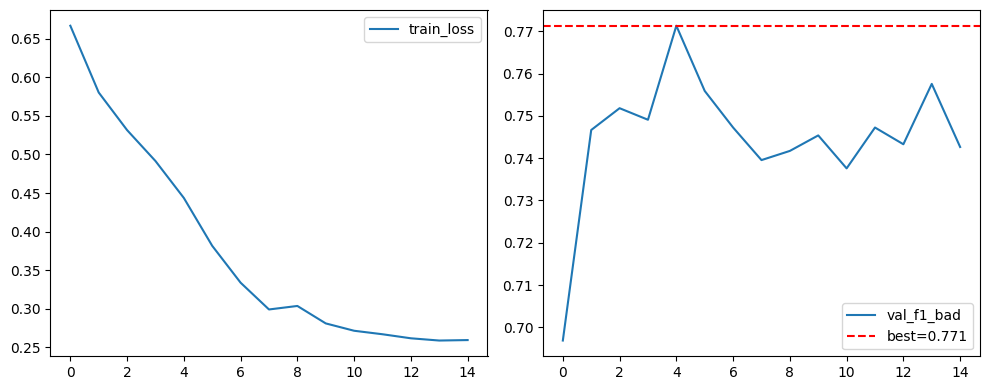

Результаты сохранены


,Accuracy,F1-macro,F1-bad,ROC-AUC
Модель,,,,
Whisper-small frozen + SVM (exp_30),0.8300,0.7990,0.7220,0.8900
Whisper-small finetune (8 слоя),NaN,NaN,NaN,NaN
Whisper-medium finetune (8 слоя) [этот эксперимент],0.8149,0.7959,0.7336,0.9089


In [6]:
import json
train_utils.load_best_checkpoint(model, best_ckpt, DEVICE)

print(f"\nОбучение: {train_time_sec:.1f} с | best val_f1={best_f1:.4f}")

with mlflow.start_run(run_id=_run_id):
    val_proba, val_true = eval_loader(val_loader)
    optimal_threshold = find_optimal_threshold(val_true, val_proba)
    json.dump({"threshold": float(optimal_threshold)}, open(exp_dir / "threshold.json", "w"))
    print(f"Оптимальный порог: {optimal_threshold:.2f}")

    test_proba, test_true = eval_loader(test_loader)
    test_metrics = evaluate(test_true, test_proba, threshold=optimal_threshold, verbose=True)
    pd.DataFrame({
        "path":    paths_test,
        "y_true":  test_true,
        "y_pred":  (test_proba >= optimal_threshold).astype(int),
        "y_proba": test_proba,
    }).to_csv(exp_dir / "test_predictions.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(train_losses, label="train_loss"); axes[0].legend()
    axes[1].plot(val_f1s, label="val_f1_bad")
    axes[1].axhline(best_f1, color="r", linestyle="--", label=f"best={best_f1:.3f}")
    axes[1].legend()
    plt.tight_layout()
    fig.savefig(exp_dir / "training_curves.png", dpi=120)
    plt.show()

    save_result_csv(
        exp_dir=exp_dir,
        experiment_id="exp_whisper_medium_finetune",
        experiment_name=f"Whisper-medium fine-tuning (верхние {N_UNFREEZE} слоя)",
        model="WhisperClassifier (partial finetune, medium)",
        accuracy=test_metrics["accuracy"],
        f1_macro=test_metrics["f1_macro"],
        f1_bad=test_metrics["f1_bad"],
        roc_auc=test_metrics["roc_auc"],
        precision_bad=test_metrics["precision_bad"],
        recall_bad=test_metrics["recall_bad"],
        threshold=test_metrics["threshold"],
        embed_dim=1024,
        embed_dim_note="Whisper-medium encoder 1024-dim, mean pooling → head=Linear(1024+n_letters, 2)",
        notes=(
            f"SpecAugment + partial finetune | "
            f"n_unfreeze={N_UNFREEZE}/24 | lr_encoder=5e-6 lr_head=1e-4 | warmup=2ep | "
            f"batch={BATCH_SIZE} | thr={optimal_threshold:.2f}"
        ),
        num_params=n_params_trainable,
        train_time_sec=train_time_sec,
    )
    log_artifact_if_exists(exp_dir / "training_curves.png")
    print("Результаты сохранены")

comparison = pd.DataFrame([
    {"Модель": "Whisper-small frozen + SVM (exp_30)",
     "Accuracy": 0.830, "F1-macro": 0.799, "F1-bad": 0.722, "ROC-AUC": 0.890},
    {"Модель": f"Whisper-small finetune ({N_UNFREEZE} слоя)",
     "Accuracy": None, "F1-macro": None, "F1-bad": None, "ROC-AUC": None},
    {"Модель": f"Whisper-medium finetune ({N_UNFREEZE} слоя) [этот эксперимент]",
     "Accuracy": test_metrics["accuracy"],
     "F1-macro": test_metrics["f1_macro"],
     "F1-bad":   test_metrics["f1_bad"],
     "ROC-AUC":  test_metrics["roc_auc"]},
])
display(comparison.set_index("Модель").round(4))
